In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from tqdm import tqdm

n = 5
mechanisms = ['MCAR', 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']

mr_values = ["05", "10", "15", "20", "25"]

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
colors = {'MCAR': (0.2, 0.2, 0.8), 'MAR_l': (0.8, 0.2, 0.2), 'MAR_m': (0.2, 0.8, 0.2),
        'MAR_h': (0.5, 0.2, 0.1),'MNAR_l': (0.0, 0.2, 0.2), 'MNAR_m': (0.2, 0.2, 0.2), 'MNAR_h':(0.9, 0.2, 0.8)}
markers = {'MCAR': 'o', 'MAR_l': 's', 'MAR_m': 'D', 'MAR_h': '^', 'MNAR_l': 'X', 'MNAR_m': 'P', 'MNAR_h': 'H'}


In [ ]:
class ConfusionMatrix:

    metrics_table_mec = {mec: pd.DataFrame(columns=['MR', 'Accuracy', 'Precision', 'Recall', 'F1_Score']) 
            for mec in mechanisms}

    def __init__(self, metric):
        self.metric = metric
        self.patients = [patient for patient in os.listdir(f"Patients/{self.metric}") 
                         if os.path.isdir(os.path.join(f"Patients/{self.metric}", patient))]
        self._plot_og_anomalies()
        self._metrics_df()

    def _intervals_overlap(self, a, b):
        """Verifica se os intervalos a e b se sobrepõem"""
        return max(a[0], b[0]) <= min(a[1], b[1])

    def _match_event_intervals(self, y_true, y_pred):
        """
        Compara listas de intervalos (eventos reais e previstos).
        Cada intervalo é uma tupla: (inicio, fim)

        Retorna TP, FP, FN
        """
        matched = set()

        for i, pred in enumerate(y_pred):
            for j, true in enumerate(y_true):
                if self._intervals_overlap(pred, true):
                    matched.add(j)
                    break  # conta só uma correspondência

        TP = len(matched)
        FP = len(y_pred) - TP
        FN = len(y_true) - TP

        return TP, FP, FN 
    
    # Iterar sobre os pacientes e contar as tuplas no dataset completo (df_full)
    def _plot_og_anomalies(self):
        tuples_count = {}
        for patient in self.patients:
            try:
                df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
                tuples_count[patient] = len(df_full)
            except (FileNotFoundError, pd.errors.EmptyDataError):
                print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
                tuples_count[patient] = 0
                self.patients.remove(patient)

        # Plotar os resultados
        plt.figure(figsize=(15, 6))
        plt.bar(tuples_count.keys(), tuples_count.values(), color='skyblue')
        plt.xlabel('Pacientes')
        plt.ylabel('Quantidade de Tuplas')
        plt.title('Quantidade de Tuplas nos Datasets de Todos os Pacientes')
        plt.xticks(rotation=45)
        # Adicionar os valores absolutos acima de cada barra
        for i, (patient, count) in enumerate(tuples_count.items()):
            plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=8)
        plt.show()

    def _metrics_df(self):

        print(f"Calculando métricas para {self.metric}...")

        for mec in mechanisms:

            results = {}
            absolute = {}

            # Adicionar barra de progresso
            for patient in tqdm(self.patients, desc=f"Processando pacientes para {mec}"):
                
                # Carregar df_full
                try:
                    df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', header=None)
                except (FileNotFoundError, pd.errors.EmptyDataError):
                    print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
                    continue
                
                # Inicializar dfs_miss
                dfs_miss = {}
                for mr_value in mr_values:
                    dfs_miss[mr_value] = {}
                    for i in range(1, n + 1):
                        file_path = f'Patients/{self.metric}/{patient}/Anomalies/{mec}/{i}/{patient}_anomalies_{mec}_{i}_{mr_value}.csv'
                        if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
                            dfs_miss[mr_value][i] = pd.read_csv(file_path, usecols=[1, 2], header=None)
                        else:
                            if not os.path.exists(file_path):
                                continue
                            elif os.path.getsize(file_path) == 0:
                                dfs_miss[mr_value][i] = pd.DataFrame(columns=[1, 2])  

                precision_list = {mr: [] for mr in mr_values}
                recall_list = {mr: [] for mr in mr_values}

                for mr, dfs in dfs_miss.items():
                    for key, df_miss in dfs.items():
                        y_true_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_full[1], df_full[1])]
                        y_pred_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_miss[1], df_miss[1])]

                        TP, FP, FN = self._match_event_intervals(y_true_intervals, y_pred_intervals)

                        if mr not in absolute:
                            absolute[mr] = {'TP': [], 'FP': [], 'FN': []}
                        absolute[mr]['TP'].append(TP)
                        absolute[mr]['FP'].append(FP)
                        absolute[mr]['FN'].append(FN)

                        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
                        recall = TP / (TP + FN) if (TP + FN) > 0 else 0

                        precision_list[mr].append(precision)
                        recall_list[mr].append(recall)

                mean_precision_by_mr = {mr: [] for mr in mr_values}
                mean_recall_by_mr = {mr: [] for mr in mr_values}

                for mr in mr_values:
                    precision_sum = sum(precision_list[mr])
                    recall_sum = sum(recall_list[mr])
                    count = len(precision_list[mr])

                    mean_precision_by_mr[mr] = precision_sum / count if count > 0 else 0
                    mean_recall_by_mr[mr] = recall_sum / count if count > 0 else 0

                for mr in mr_values:
                    if mr not in results:
                        results[mr] = {'precision': [], 'recall': []}
                    results[mr]['precision'].append(mean_precision_by_mr[mr])
                    results[mr]['recall'].append(mean_recall_by_mr[mr])

            # Inicializar os valores totais de TP, FP, FN
            # Inicializar os valores totais de TP, FP, FN por MR
            total_tp_by_mr = {mr: sum(values['TP']) for mr, values in absolute.items()}
            total_fp_by_mr = {mr: sum(values['FP']) for mr, values in absolute.items()}
            total_fn_by_mr = {mr: sum(values['FN']) for mr, values in absolute.items()}

            # Inicializar listas para armazenar as métricas
            accuracy_list = []
            precision_list = []
            f1_list = []
            recall_list = []

            # Calcular métricas para cada MR
            for mr in mr_values:
                tp = total_tp_by_mr[mr]
                fp = total_fp_by_mr[mr]
                fn = total_fn_by_mr[mr]
                total_instances = tp + fp + fn

                # Calcular acurácia, precisão, revocação e F1
                accuracy = tp / total_instances if total_instances > 0 else 0
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

                # Adicionar métricas às listas
                accuracy_list.append(accuracy * 100)
                precision_list.append(precision * 100)
                recall_list.append(recall * 100)
                f1_list.append(f1 * 100)

            # Criar um DataFrame com as métricas
            metrics_table = pd.DataFrame({
                'MR': mr_values,
                'Accuracy': accuracy_list,
                'Precision': precision_list,
                'Recall': recall_list,
                'F1_Score': f1_list
            })

            # Adicionar a tabela de métricas ao DataFrame geral
            self.metrics_table_mec[mec] = metrics_table

            # Exibir a tabela
            print(metrics_table)



In [26]:
def metric_lineplot(matrix):
        fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

        for idx, metric in enumerate(metric_names):
            for mec_name, table in matrix.metrics_table_mec.items():
                axs[idx].plot(table['MR'], table[metric], marker=markers.get(mec_name, 'o'), label=mec_name, color=colors.get(mec_name, 'black'))
                axs[idx].set_title(metric)
                axs[idx].set_ylim(0, 100)
                axs[idx].set_xticks(mr_values)
                #axs[idx].set_xlabel('Missing Rate (%)')
                axs[idx].set_ylabel('Value (%)' if idx == 0 else "")
                axs[idx].grid(True)

        fig.supxlabel('Missing Rate (%)', fontsize=10, y=0.05)

        handles, labels = axs[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=len(mechanisms), fontsize=10)
        for ax in axs:
            ax.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.savefig(f'Plots/Lineplots/metrics_{matrix.metric}.png', dpi=600, bbox_inches='tight')
        plt.show() 

def pr_lineplot(matrix):
    plt.figure(figsize=(8, 6))

    for mec_name, table in matrix.metrics_table_mec.items():
        plt.plot(table['Recall'], table['Precision'], marker=markers.get(mec_name, 'o'), label=mec_name, color=colors.get(mec_name, 'black'))
    
    plt.xlabel('Recall (%)')
    plt.ylabel('Precision (%)')
    plt.xlim(20, 100)
    plt.ylim(20, 100)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Mechanism', loc='upper left', fontsize=10)
    plt.savefig(f'Plots/Lineplots/pr_plot_{matrix.metric}.png', dpi=600, bbox_inches='tight')
    plt.show()

Arquivo completo não encontrado ou vazio para o paciente AJ7TSV9. Pulando...


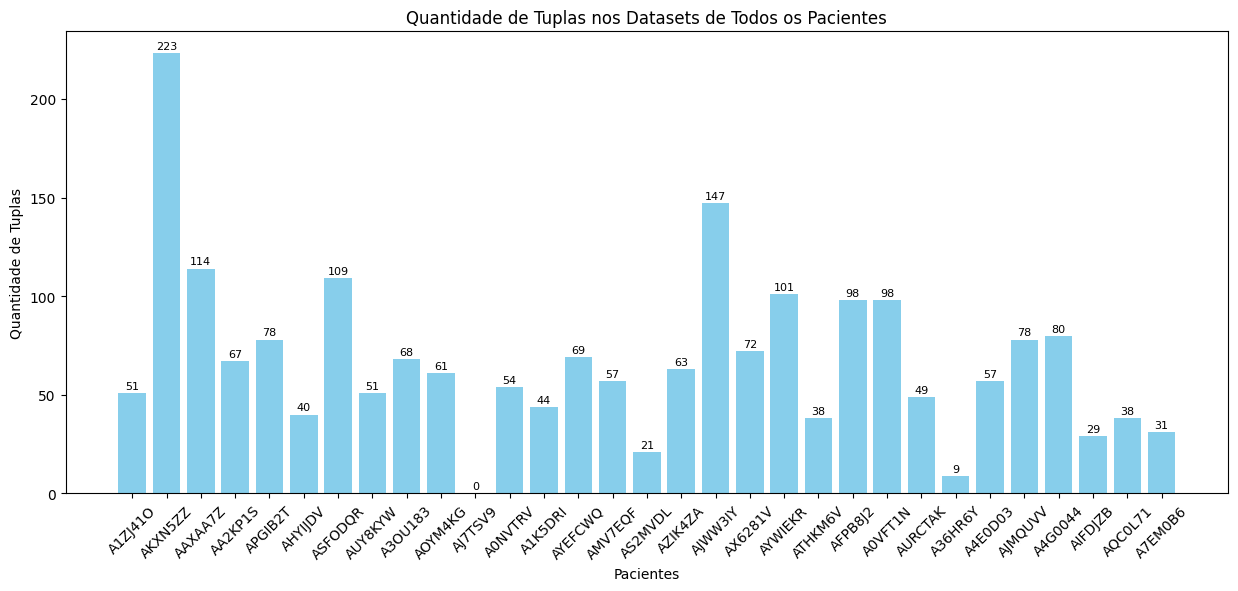

Calculando métricas para RHR...


Processando pacientes para MCAR: 100%|██████████| 31/31 [02:20<00:00,  4.53s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  79.381188  89.281737  87.742818  88.505589
1  10  68.475533  83.011693  79.635203  81.288401
2  15  60.450355  77.904372  72.959416  75.350852
3  20  53.898949  72.995155  67.323301  70.044596
4  25  48.220551  69.180193  61.413589  65.065945


Processando pacientes para MAR_l: 100%|██████████| 31/31 [02:06<00:00,  4.08s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  72.708590  88.053758  80.665755  84.198001
1  10  57.370054  79.345494  67.441860  72.911018
2  15  46.096096  72.277810  55.996352  63.103803
3  20  36.910509  66.532798  45.326037  53.919175
4  25  28.603269  60.677699  35.111719  44.482958


...

   MR   Accuracy  Precision     Recall   F1_Score
0  05  71.601769  76.658777  91.564067  83.451085
1  10  59.924767  69.461964  81.358869  74.941196
2  15  49.720082  64.153990  68.846329  66.417385
3  20  44.079035  61.755690  60.629275  61.187299
4  25  38.909440  60.990014  51.801186  56.021304


Processando pacientes para MNAR_m: 100%|██████████| 31/31 [02:31<00:00,  4.89s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  74.097775  80.099743  90.816233  85.122024
1  10  65.307990  74.115203  84.605563  79.013713
2  15  57.654304  69.091646  77.692658  73.140159
3  20  52.638880  65.626287  72.676699  68.971785
4  25  45.485587  61.897954  63.173735  62.529337


Processando pacientes para MNAR_h: 100%|██████████| 31/31 [02:17<00:00,  4.44s/it]

   MR   Accuracy  Precision     Recall   F1_Score
0  05  78.189740  88.804855  86.739626  87.760092
1  10  66.474034  83.436010  76.580027  79.861144
2  15  56.289947  76.232179  68.271774  72.032716
3  20  47.781195  70.800781  59.507524  64.664784
4  25  41.784311  67.402277  52.366621  58.940669


In [29]:
results_rhr = ConfusionMatrix("RHR")

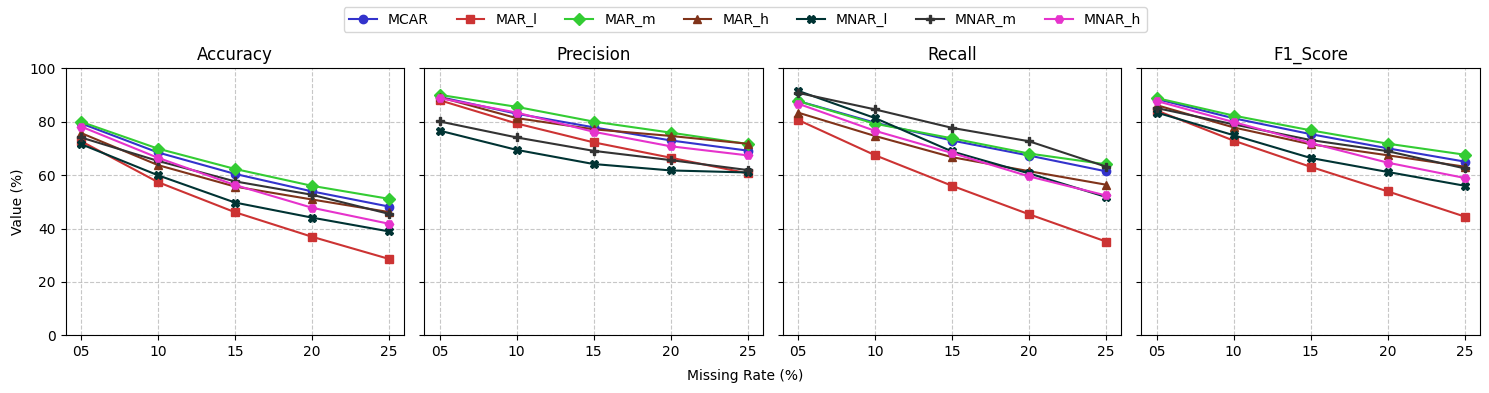

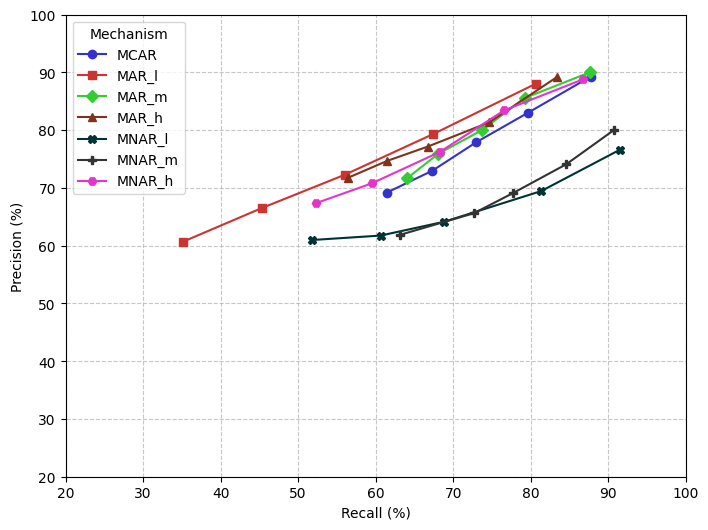

In [30]:
metric_lineplot(results_rhr)
pr_lineplot(results_rhr)

Arquivo completo não encontrado ou vazio para o paciente AS2MVDL. Pulando...


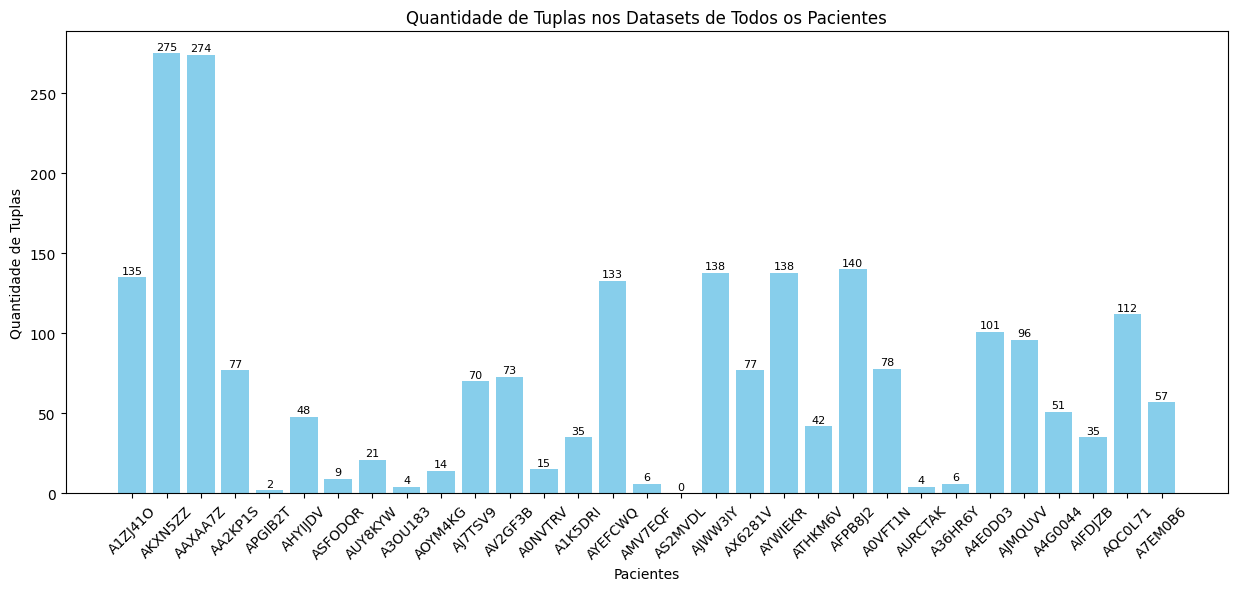

Calculando métricas para HROS...


Processando pacientes para MCAR: 100%|██████████| 31/31 [02:44<00:00,  5.30s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  80.354716  89.644168  88.577060  89.107419
1  10  69.477098  82.928796  81.072132  81.989955
2  15  61.651210  77.663399  74.938904  76.276830
3  20  56.434893  74.011440  70.382341  72.151285
4  25  52.249770  70.045137  67.284194  68.636912


Processando pacientes para MAR_l: 100%|██████████| 31/31 [02:35<00:00,  5.02s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  74.784483  89.394590  82.065432  85.573366
1  10  63.326446  83.363554  72.487190  77.545857
2  15  54.702886  79.791976  63.500197  70.719930
3  20  47.500000  75.476695  56.168703  64.406780
4  25  41.972477  71.325167  50.492708  59.127625


...

   MR   Accuracy  Precision     Recall   F1_Score
0  05  82.025316  90.865385  89.396926  90.125174
1  10  73.677127  87.898251  81.994482  84.843788
2  15  66.217244  84.341700  75.498620  79.675541
3  20  58.538750  81.391816  67.583760  73.847877
4  25  51.443326  76.258710  61.253449  67.937396


Processando pacientes para MNAR_m: 100%|██████████| 31/31 [02:38<00:00,  5.11s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  56.507497  73.772514  70.713441  72.210594
1  10  45.708245  66.162455  59.653134  62.739408
2  15  39.949673  62.469552  52.566023  57.091485
3  20  34.238068  55.858899  46.937328  51.010966
4  25  29.947917  52.968270  40.796216  46.092184


Processando pacientes para MNAR_h: 100%|██████████| 31/31 [02:25<00:00,  4.68s/it]

   MR   Accuracy  Precision     Recall   F1_Score
0  05  46.765181  68.766548  59.377217  63.727896
1  10  34.454687  58.872865  45.376429  51.251002
2  15  27.208169  51.568409  36.547103  42.777393
3  20  22.963475  46.033029  31.422940  37.350075
4  25  20.585847  43.793189  27.977927  34.143056


In [17]:
results_hros = ConfusionMatrix("HROS")


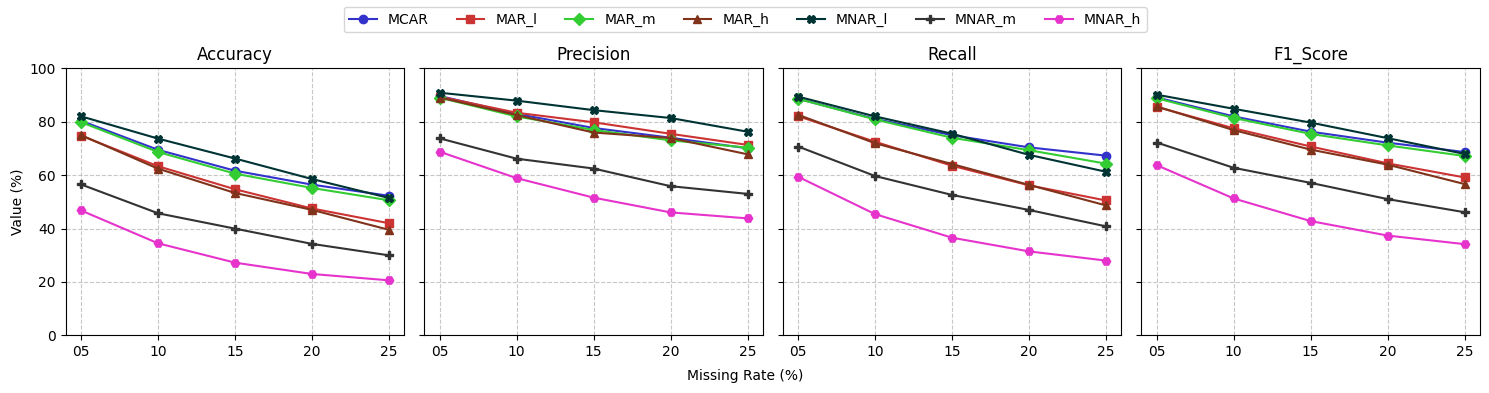

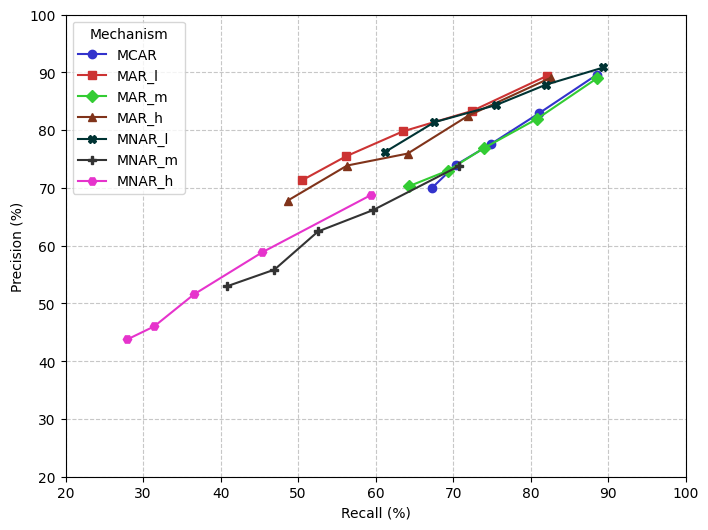

In [28]:
metric_lineplot(results_hros)
pr_lineplot(results_hros)